In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from wordcloud import WordCloud
from collections import Counter


In [2]:
# Load the dataset
# data = pd.read_csv('political_bias.csv', dtype=str) dont know why this doesnt work 
data = pd.read_csv('political_bias.csv')

In [3]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3458 non-null   object
 1   Link    3458 non-null   object
 2   Text    3397 non-null   object
 3   Source  3458 non-null   object
 4   Bias    3458 non-null   object
dtypes: object(5)
memory usage: 135.2+ KB


In [4]:
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)

Title      0
Link       0
Text      61
Source     0
Bias       0
dtype: int64


In [5]:
# Drop rows with any null (NaN) values
data = data.dropna()

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3397 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3397 non-null   object
 1   Link    3397 non-null   object
 2   Text    3397 non-null   object
 3   Source  3397 non-null   object
 4   Bias    3397 non-null   object
dtypes: object(5)
memory usage: 159.2+ KB


In [6]:
# Drop rows where 'Text' column contains 'Error fetching article'
data = data[data['Text'] != 'Error fetching article']

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2765 non-null   object
 1   Link    2765 non-null   object
 2   Text    2765 non-null   object
 3   Source  2765 non-null   object
 4   Bias    2765 non-null   object
dtypes: object(5)
memory usage: 129.6+ KB


In [7]:
# Clean the data to fix encoding issues and remove unwanted characters
def fix_encoding_and_special_chars(text):
    # Fix common encoding issues
    text = text.replace('â€™', '').replace('â€œ', '"').replace('â€', '"').replace('â€™','"').replace('â€˜','"')  # Replace known encoding issues
    
    # Remove special characters and numbers using regular expression (keeps only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    return text

# Apply the function to clean the cols
data['Title'] = data['Title'].apply(fix_encoding_and_special_chars)
data['Text'] = data['Text'].apply(fix_encoding_and_special_chars)
data['Source'] = data['Source'].apply(fix_encoding_and_special_chars)
data['Bias'] = data['Bias'].apply(fix_encoding_and_special_chars)

# Convert the data to strings 
data['Title'] = data['Title'].astype('string')
data['Text'] = data['Text'].astype('string')
data['Link'] = data['Link'].astype('string')
data['Source'] = data['Source'].astype('string')
data['Bias'] = data['Bias'].astype('string')

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2765 non-null   string
 1   Link    2765 non-null   string
 2   Text    2765 non-null   string
 3   Source  2765 non-null   string
 4   Bias    2765 non-null   string
dtypes: string(5)
memory usage: 129.6 KB


In [8]:
# Show the first few rows of the dataset
data.head()

,Title,Link,Text,Source,Bias
0,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,TheDispatch,lean right
1,Why Shrubland Makes Southern Californias Wildf...,https://thedispatch.com/newsletter/techne/why-...,Welcome back to Techne In Star Trek writers go...,TheDispatch,lean right
2,Los Angeles Destruction Was Fueled by Bad Poli...,https://thedispatch.com/newsletter/capitolism/...,As fire still rages in the Los Angeles area Iv...,TheDispatch,lean right
3,Acquiring Greenland Is a Good Idea Threatening...,https://thedispatch.com/article/acquiring-gree...,Whether it was Will Rogers or Tony Soprano the...,TheDispatch,lean right
4,Assessing Trumps Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,Happy Friday If anyone was wondering Belgiums ...,TheDispatch,lean right


In [9]:
# Summary statistics of numerical columns (if any)
data.describe()

,Title,Link,Text,Source,Bias
count,2765,2765,2765,2765,2765
unique,2511,2280,2434,21,5
top,Trumps Supposed Unity Message Is a Gloating Th...,https://www.thenation.com/article/politics/dem...,A new bill in Mississippi could turn bounty hu...,Alternet,left
freq,7,7,5,596,1376


In [10]:
# noticed that not all rows are unique, so we will drop duplicates
data = data.drop_duplicates(subset='Title', keep='first')
data = data.drop_duplicates(subset='Text', keep='first')
data = data.drop_duplicates(subset='Link', keep='first')

In [11]:
# Verify by checking the data info
data.describe()

,Title,Link,Text,Source,Bias
count,2224,2224,2224,2224,2224
unique,2224,2224,2224,21,5
top,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,Alternet,left
freq,1,1,1,483,1150


In [12]:
# Checking the distribution of the 'Bias' column
bias_counts = data['Bias'].value_counts()
print(bias_counts)
# over representation of left bias

Bias
left          1150
right          382
lean left      305
center         202
lean right     185
Name: count, dtype: Int64


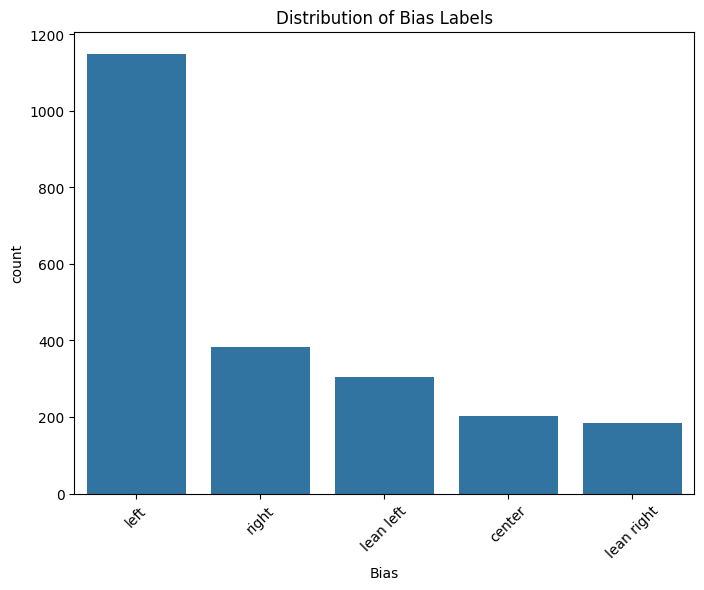

In [13]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Bias', order=data['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)
plt.show()

In [14]:
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords
nltk.download('stopwords')

# Get the set of English stopwords
stop_words = set(stopwords.words('english'))

# Updated clean_text function to remove punctuation and stopwords
def clean_text(text):
    text = text.lower()  # Convert text to lowercase
    text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Split text into words
    text = ' '.join([word for word in words if word not in stop_words]) # Remove stopwords
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# Apply the clean_text function to the 'Text' column
data['cleaned_text'] = data['Text'].apply(clean_text)

# Most common words (excluding stopwords)
words = ' '.join(data['cleaned_text']).split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)

# Display the 20 most common words
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
common_words_df

,Word,Frequency
0,trump,9649
1,said,8341
2,president,4765
3,us,4118
4,people,3468
5,trumps,3419
6,would,3336
7,also,3076
8,one,2862
9,new,2656


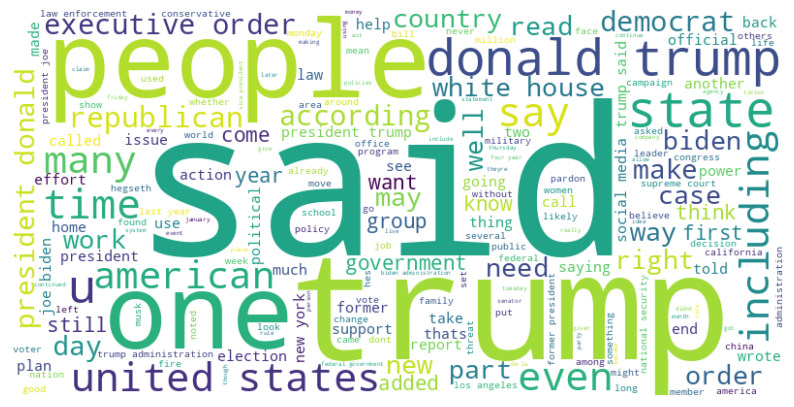

In [16]:
# Generate a wordcloud
text = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


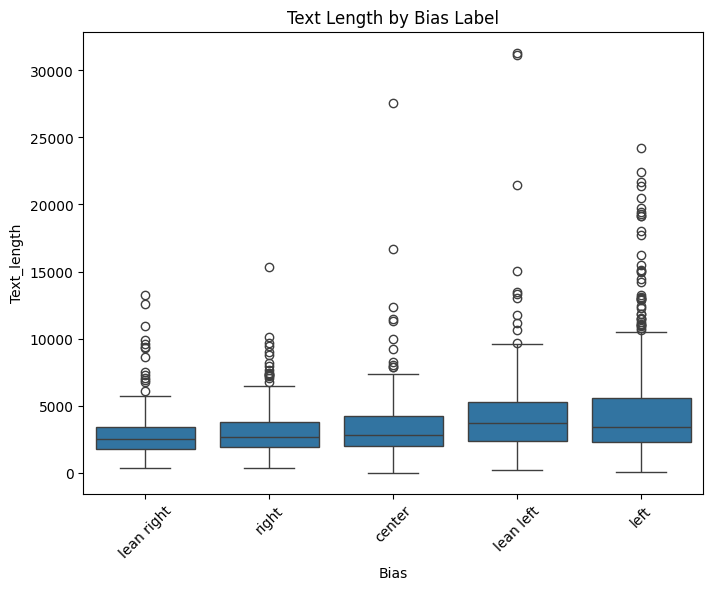

In [17]:
# Investigating length of articles by bias
data['Text_length'] = data['Text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='Text_length')
plt.title('Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

In [18]:
## i think we should drop the outlier data. wdyt? can wait till new data is in 

In [19]:
# Group by 'Bias' and get text length analysis for each group
grouped_description = data.groupby('Bias').describe()

# Display the result
print(grouped_description)

           Text_length                                                    \
                 count         mean          std    min      25%     50%   
Bias                                                                       
center           202.0  3550.292079  2859.330496    3.0  2018.75  2785.5   
lean left        305.0  4288.947541  3396.918928  177.0  2357.00  3671.0   
lean right       185.0  2988.097297  2169.002348  348.0  1790.00  2499.0   
left            1150.0  4253.715652  3020.431239   15.0  2268.75  3421.0   
right            382.0  3030.094241  1757.916638  363.0  1886.75  2625.0   

                              
                75%      max  
Bias                          
center      4218.25  27565.0  
lean left   5289.00  31337.0  
lean right  3422.00  13272.0  
left        5546.75  24224.0  
right       3777.75  15356.0  


In [20]:
import scipy.stats as stats

# Perform ANOVA to compare the means of Text_length across different Bias categories
f_stat, p_val = stats.f_oneway(data[data['Bias'] == 'lean right']['Text_length'],
                                data[data['Bias'] == 'right']['Text_length'],
                                data[data['Bias'] == 'center']['Text_length'],
                                data[data['Bias'] == 'lean left']['Text_length'],
                                data[data['Bias'] == 'left']['Text_length'])

print("ANOVA p-value:", p_val)

#statistically significant difference in the means of text lengths between the different bias categories

ANOVA p-value: 1.0814214484089497e-16


In [21]:
# Perform Levene's test to compare the variances of Text_length across different Bias categories
w_stat, p_val_levene = stats.levene(data[data['Bias'] == 'lean right']['Text_length'],
                                    data[data['Bias'] == 'right']['Text_length'],
                                    data[data['Bias'] == 'center']['Text_length'],
                                    data[data['Bias'] == 'lean left']['Text_length'],
                                    data[data['Bias'] == 'left']['Text_length'])

print("Levene's Test p-value:", p_val_levene)

#statistically significant difference in the variance of text lengths between the different bias categories

Levene's Test p-value: 1.5824148620918292e-10


Source
Alternet                    483
Apnews                      390
BreitBart                   221
NewYorkPost                 132
Huffpost                    128
usatoday                     97
reason                       88
StraightArrowNews            81
abcnews                      77
npr                          75
IndependentJournalReview     72
MotherJones                  59
TheDailyBeast                59
nbcnews                      56
TheFederalist                40
TheFreePress                 36
BlazeMedia                   35
cnbc                         33
TheNation                    31
TheDispatch                  17
TheWashingtonFreeBeacon      14
Name: count, dtype: Int64


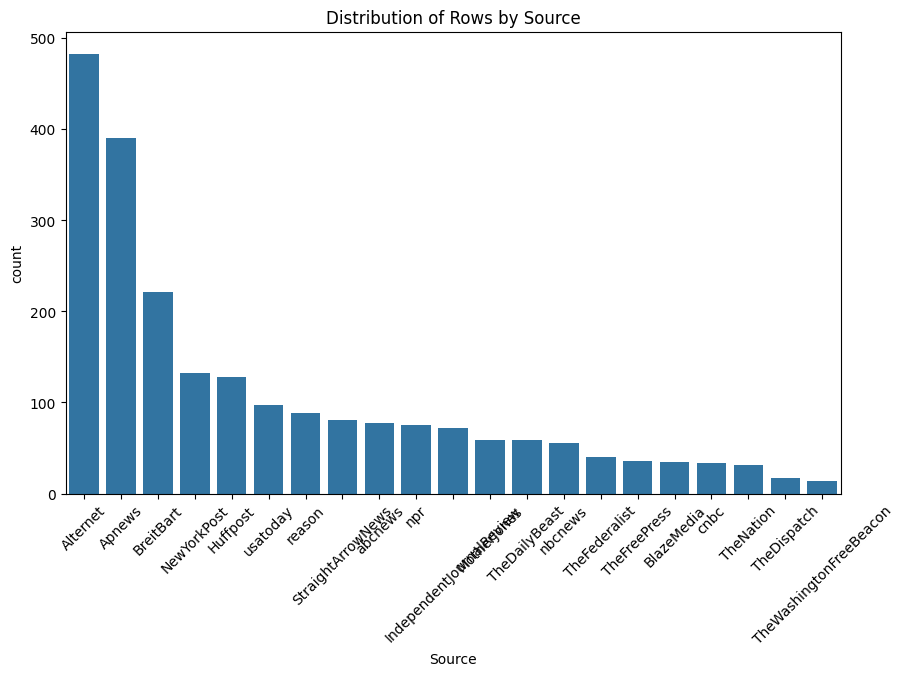

In [22]:
## check distribution of news sources
source_counts = data['Source'].value_counts()

# Print the distribution
print(source_counts)

# Plot the distribution using a bar plot
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Source', order=source_counts.index)
plt.title('Distribution of Rows by Source')
plt.xticks(rotation=45)
plt.show()

Bias                      center  lean left  lean right  left  right
Source                                                              
Alternet                       0          0           0   483      0
Apnews                         0          0           0   390      0
BreitBart                      0          0           0     0    221
NewYorkPost                    0          0         132     0      0
Huffpost                       0          0           0   128      0
usatoday                       0         97           0     0      0
reason                        88          0           0     0      0
StraightArrowNews             81          0           0     0      0
abcnews                        0         77           0     0      0
npr                            0         75           0     0      0
IndependentJournalReview       0          0           0     0     72
MotherJones                    0          0           0    59      0
TheDailyBeast                  0  

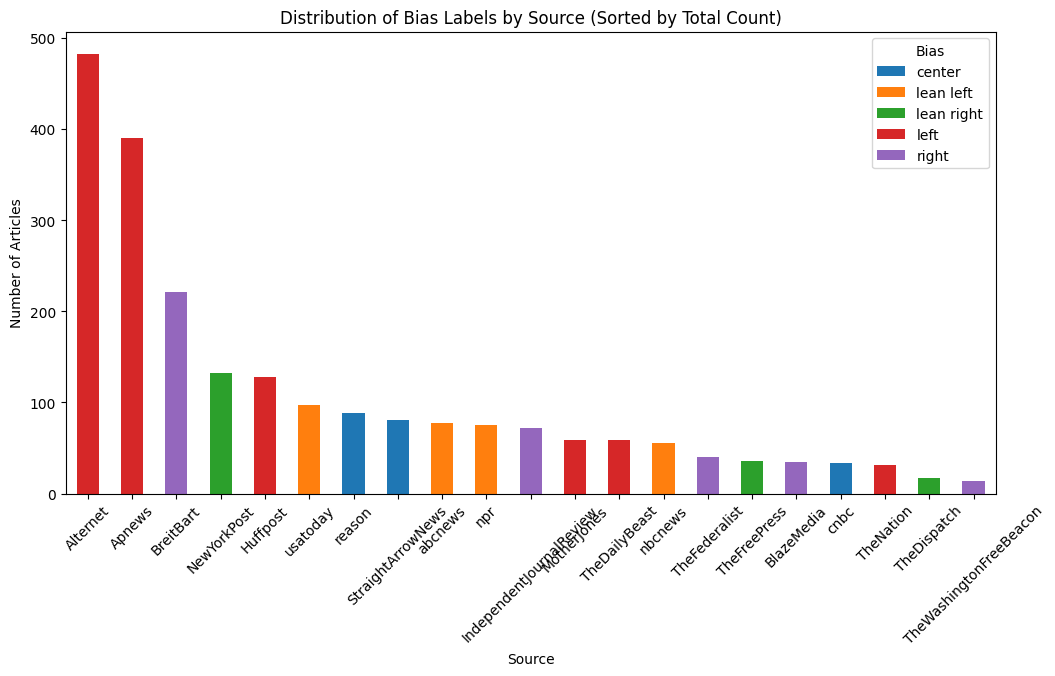

In [23]:
# Group by 'Source' and 'Bias' and get the count for each combination
bias_distribution_by_source = data.groupby(['Source', 'Bias']).size().unstack(fill_value=0)

# Sum the counts for each source and sort by the total count
bias_distribution_by_source['Total'] = bias_distribution_by_source.sum(axis=1)
bias_distribution_by_source = bias_distribution_by_source.sort_values(by='Total', ascending=False)

# Drop the 'Total' column from the plot
bias_distribution_by_source.drop('Total', axis=1, inplace=True)

# Print the sorted distribution
print(bias_distribution_by_source)

# Plot the distribution using a stacked bar plot
bias_distribution_by_source.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Bias Labels by Source (Sorted by Total Count)')
plt.xlabel('Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.legend(title='Bias')
plt.show()

Bias                      center  lean left  lean right   left  right
Source                                                               
Alternet                     0.0        0.0         0.0  100.0    0.0
TheFederalist                0.0        0.0         0.0    0.0  100.0
reason                     100.0        0.0         0.0    0.0    0.0
npr                          0.0      100.0         0.0    0.0    0.0
nbcnews                      0.0      100.0         0.0    0.0    0.0
cnbc                       100.0        0.0         0.0    0.0    0.0
abcnews                      0.0      100.0         0.0    0.0    0.0
TheWashingtonFreeBeacon      0.0        0.0         0.0    0.0  100.0
TheNation                    0.0        0.0         0.0  100.0    0.0
TheFreePress                 0.0        0.0       100.0    0.0    0.0
TheDispatch                  0.0        0.0       100.0    0.0    0.0
Apnews                       0.0        0.0         0.0  100.0    0.0
TheDailyBeast       

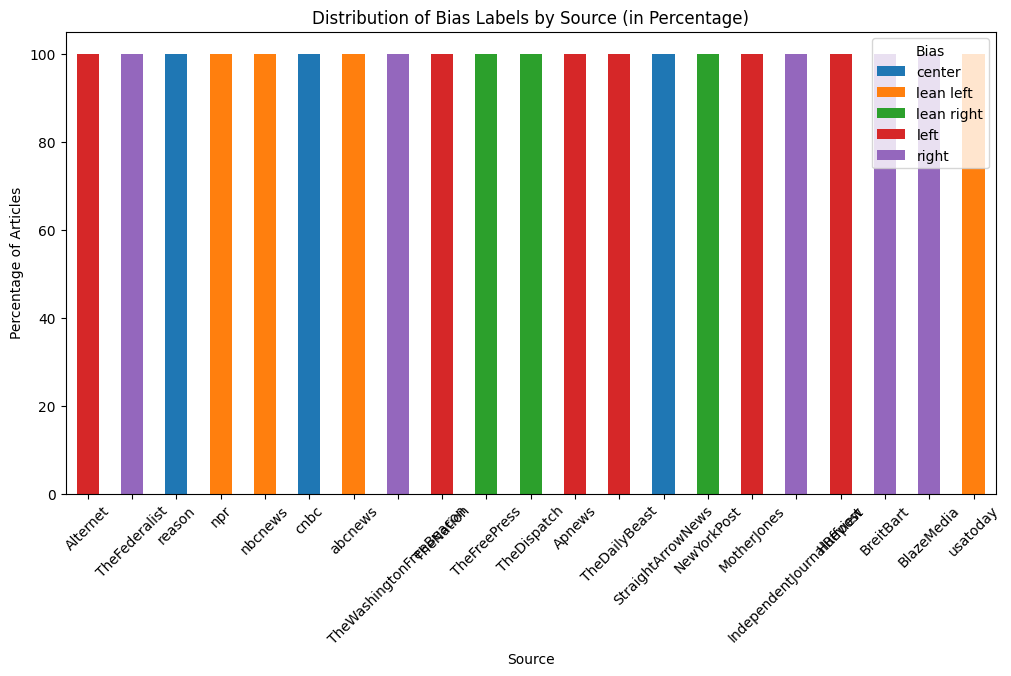

In [24]:
# Group by 'Source' and 'Bias' and get the count for each combination
bias_distribution_by_source = data.groupby(['Source', 'Bias']).size().unstack(fill_value=0)

# Normalize the counts by dividing by the row sums (to get percentages)
bias_distribution_by_source = bias_distribution_by_source.div(bias_distribution_by_source.sum(axis=1), axis=0) * 100

# Sort by the total percentage (optional, to maintain consistency)
bias_distribution_by_source['Total'] = bias_distribution_by_source.sum(axis=1)
bias_distribution_by_source = bias_distribution_by_source.sort_values(by='Total', ascending=False)

# Drop the 'Total' column from the plot
bias_distribution_by_source.drop('Total', axis=1, inplace=True)

# Print the normalized distribution
print(bias_distribution_by_source)

# Plot the distribution using a stacked column chart in percentages
bias_distribution_by_source.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Bias Labels by Source (in Percentage)')
plt.xlabel('Source')
plt.ylabel('Percentage of Articles')
plt.xticks(rotation=45)
plt.legend(title='Bias')
plt.show()

# all sources produce only one type of bias, hence source is a strong predictor of bias

EDA conclusions:
1. Source is a one to one mapping to classification. i.e. Source == Bias 
2. Text_Length is potentially a predictor of bias 
3. Over representation of left articles 

In [ ]:
#pip install pyldavis

In [43]:
import numpy as np
import nltk
from nltk.corpus import stopwords
import gensim
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
import pyLDAvis.gensim
import pandas as pd

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

stop = set(stopwords.words('english'))

def preprocess_text(text):
    corpus = []
    lem = WordNetLemmatizer()
    for news in text:
        words = [w for w in word_tokenize(news) if w.lower() not in stop]
        words = [lem.lemmatize(w) for w in words if len(w) > 2]
        corpus.append(words)
    return corpus

def get_lda_by_bias(data):
    lda_models = {}
    bow_corpus_dict = {}

    for bias_label in data['Bias'].unique():
        subset = data[data['Bias'] == bias_label]['cleaned_text'].dropna().tolist()
        corpus = preprocess_text(subset)

        dic = gensim.corpora.Dictionary(corpus)
        bow_corpus = [dic.doc2bow(doc) for doc in corpus]

        lda_model = gensim.models.LdaMulticore(
            bow_corpus, num_topics=4, id2word=dic, passes=10, workers=2
        )

        lda_models[bias_label] = lda_model
        bow_corpus_dict[bias_label] = (bow_corpus, dic)

    return lda_models, bow_corpus_dict

def plot_lda_vis(lda_model, bow_corpus, dic):
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim.prepare(lda_model, bow_corpus, dic)
    return vis

def show_topics_by_bias(lda_models):
    for bias_label, lda_model in lda_models.items():
        print(f"\nTopics for Bias: {bias_label}")
        topics = lda_model.print_topics(num_words=5)
        for topic in topics:
            print(topic)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/foongming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
lda_models, bow_corpus_dict = get_lda_by_bias(data)

In [45]:
bias_label = "left"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=98399) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=98399) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=98399) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=98399) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/f

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.101200  0.041989       1        1  44.339790
2      0.094492  0.039086       2        1  32.295626
1      0.031310 -0.101995       3        1  15.341529
3     -0.227002  0.020921       4        1   8.023055, topic_info=           Term         Freq        Total Category  logprob  loglift
15820       que   747.000000   747.000000  Default  30.0000  30.0000
1254        los   666.000000   666.000000  Default  29.0000  29.0000
4705         la   312.000000   312.000000  Default  28.0000  28.0000
3192       gaza   289.000000   289.000000  Default  27.0000  27.0000
98         said  4145.000000  4145.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
227    released    71.619274   220.060728   Topic4  -6.2733   1.4003
121       trump   163.291441  7622.993570   Topic4  -5.4491  -1.3205
127         war    73.372831   375.674476   Topic4  -6.2491   0.8897
376      people    72.296073  1892.009814   Topic4  -6.2639  -0.7418
136        year    59.935574  1538.253672   Topic4  -6.4514  -0.7223

[342 rows x 6 columns], token_table=       Topic      Freq            Term
term                                  
5053       1  0.128209        abortion
5053       2  0.867295        abortion
5053       3  0.003771        abortion
1096       1  0.704332  administration
1096       2  0.262898  administration
...      ...       ...             ...
861        1  0.168654           youre
861        2  0.267378           youre
861        3  0.547097           youre
861        4  0.016454           youre
25313      3  0.988626          zverev

[771 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 3, 2, 4])

In [49]:
bias_label = "lean left"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.078254 -0.009372       1        1  37.015826
2     -0.075242 -0.013741       2        1  35.034124
1      0.095800 -0.081377       3        1  15.314481
0      0.057696  0.104489       4        1  12.635569, topic_info=            Term         Freq        Total Category  logprob  loglift
297         fire   439.000000   439.000000  Default  30.0000  30.0000
170        trump  1774.000000  1774.000000  Default  29.0000  29.0000
2202     angeles   141.000000   141.000000  Default  28.0000  28.0000
142         said  1788.000000  1788.000000  Default  27.0000  27.0000
1064      school   191.000000   191.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
39    department    38.307138   231.057622   Topic4  -6.0294   0.2716
101     national    38.189561   286.806379   Topic4  -6.0325   0.0524
34           day    36.436316   422.054969   Topic4  -6.0795  -0.3809
1004     general    33.221012   141.044842   Topic4  -6.1718   0.6228
708       people    33.918756   588.493937   Topic4  -6.1511  -0.7849

[333 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
5738      2  0.951202   abortion
530       1  0.320683  according
530       2  0.247384  according
530       3  0.216843  according
530       4  0.216843  according
...     ...       ...        ...
2634      4  0.534106    yearold
8053      2  0.923285       yoon
6506      1  0.945370  zelenskyy
3124      2  0.050597        zoo
3124      4  0.927611        zoo

[644 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 3, 2, 1])

In [48]:
bias_label = "center"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.084262 -0.011956       1        1  39.574493
1     -0.032858 -0.000009       2        1  24.722087
2      0.069725 -0.070522       3        1  18.213570
3      0.047395  0.082487       4        1  17.489850, topic_info=          Term        Freq       Total Category  logprob  loglift
678        tax  117.000000  117.000000  Default  30.0000  30.0000
28        musk  113.000000  113.000000  Default  29.0000  29.0000
378     tiktok  104.000000  104.000000  Default  28.0000  28.0000
3638  ulbricht   71.000000   71.000000  Default  27.0000  27.0000
15       china   76.000000   76.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
331       like   26.579240  123.413993   Topic4  -6.1122   0.2081
168       many   25.946640  120.351954   Topic4  -6.1363   0.2092
18     company   26.053513  146.605424   Topic4  -6.1322   0.0160
96       could   26.026326  151.885585   Topic4  -6.1332  -0.0205
750    federal   26.131473  216.042201   Topic4  -6.1292  -0.3688

[343 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
7409      1  0.961454      abbott
3658      2  0.123507     abolish
3658      4  0.864549     abolish
890       1  0.889506    abortion
890       2  0.063536    abortion
...     ...       ...         ...
277       2  0.207026        year
277       3  0.320891        year
277       4  0.134567        year
2785      2  0.766194  zuckerberg
2785      4  0.204318  zuckerberg

[660 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4])

In [50]:
bias_label = "lean right"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.012128  0.100627       1        1  32.496244
3      0.063258 -0.049865       2        1  30.737574
0      0.040445 -0.025249       3        1  18.781469
1     -0.115832 -0.025513       4        1  17.984712, topic_info=            Term        Freq       Total Category  logprob  loglift
567         fire   95.000000   95.000000  Default  30.0000  30.0000
325        trump  615.000000  615.000000  Default  29.0000  29.0000
2156       agent   56.000000   56.000000  Default  28.0000  28.0000
433   california   67.000000   67.000000  Default  27.0000  27.0000
1474      pardon  104.000000  104.000000  Default  26.0000  26.0000
...          ...         ...         ...      ...      ...      ...
304        state   23.657580  170.372165   Topic4  -5.9980  -0.2587
843       school   19.539231   86.928396   Topic4  -6.1893   0.2230
122          get   19.356732   83.091395   Topic4  -6.1987   0.2587
380         also   20.766143  171.766537   Topic4  -6.1284  -0.3972
319         time   18.825546  117.171430   Topic4  -6.2265  -0.1128

[334 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
6598      1  0.089394  abortion
6598      2  0.089394  abortion
6598      3  0.893938  abortion
3079      1  0.118061    access
3079      2  0.059030    access
...     ...       ...       ...
351       2  0.333993      year
351       3  0.197110      year
351       4  0.164259      year
4573      1  0.892969  zabavsky
6350      4  0.950806       zoo

[579 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 1, 2])

In [46]:
bias_label = "right"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.025706 -0.040487       1        1  35.891204
1      0.013432 -0.058748       2        1  28.061413
2      0.081556  0.043912       3        1  19.634829
0     -0.069281  0.055324       4        1  16.412555, topic_info=          Term        Freq       Total Category  logprob  loglift
1444   hegseth   92.000000   92.000000  Default  30.0000  30.0000
129     pardon  162.000000  162.000000  Default  29.0000  29.0000
1490      vote  107.000000  107.000000  Default  28.0000  28.0000
1404    senate  153.000000  153.000000  Default  27.0000  27.0000
1465      pete   44.000000   44.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
123        one   50.362703  366.490138   Topic4  -5.8831  -0.1776
194      would   48.501630  319.798696   Topic4  -5.9208  -0.0790
12       biden   46.461237  384.584059   Topic4  -5.9638  -0.3064
445   democrat   42.760114  247.044186   Topic4  -6.0468   0.0532
167      state   43.079523  524.717942   Topic4  -6.0393  -0.6927

[348 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
0         1  0.258182       according
0         2  0.258182       according
0         3  0.332769       according
0         4  0.149172       according
203       1  0.204148  administration
...     ...       ...             ...
195       2  0.240553            year
195       3  0.210896            year
195       4  0.184534            year
7765      3  0.942609       youngblut
3793      2  0.961858        zelensky

[632 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 3, 1])